/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/1980537041.py:161: F

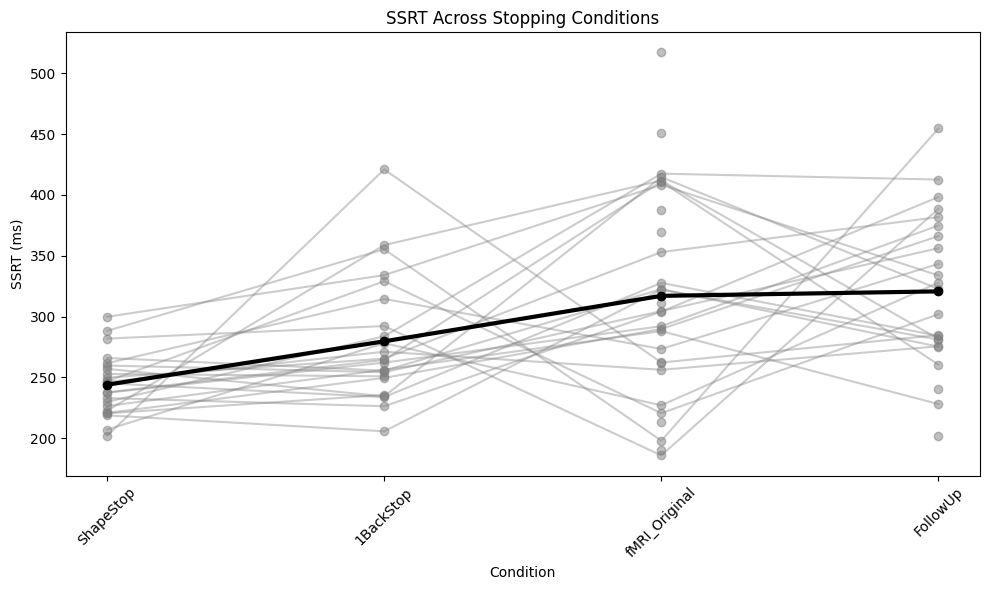

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ---------------------------
# 1. Define files and their column mappings
# ---------------------------
files_info = {
    "fMRI_Original": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/BeastfMRIN30.xlsx",
        "subject_col": "SubjID",
        "rt_col": "RT",
        "stop_acc_col": "StopAcc",
        "ssd_col": "SSD",
        "stop_go_col": "Stop1OrNoStop2",
        "go_code": 2,
        "stop_code": 1,
        "go_acc": "GoAcc",
        "stim_col": "Target1NonTarget2TempNonTarget3",
        "stim_map": {1: "Target", 2: "Non-target", 3: "Lure"}
    },
    "FollowUp": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/N23NonFMRIBeast.xlsx",
        "subject_col": "subject_id",
        "rt_col": "RT",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "SS_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "go_acc": "go_acc",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "1BackStop": {
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/1BackStoppingN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "stop_trial_type",
        "go_code": "go",
        "go_acc": "go_acc",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "NBackNoStop": {  # no stop trials
        "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/NBackNoStopN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": None,
        "ssd_col": None,
        "stop_go_col": None,
        "go_code": None,
        "stop_code": None,
        "go_acc": None,
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "ShapeStop": {
    "file": "/Users/elizabethkudriavtsev/Downloads/Poldrack_Lab_Documents/Beast/thebeastdataset/StopNoNBackN23.xlsx",
    "subject_col": "subject_ID",
    "rt_col": "rt",
    "stop_acc_col": "stop_acc",
    "ssd_col": "SS_delay",
    "stop_go_col": "SS_trial_type",
    "go_code": "go",     # <-- strings, not 0/1
    "stop_code": "stop",
    "go_acc": "go_acc",
    "shape_col": "go_stim",
    "shape_map": {"black_circle": "Circle", "black_triangle": "Triangle"}
}
}

# ---------------------------
# 2. SSRT computation function
# ---------------------------
def compute_ssrt(df, stop_go_col, stop_acc_col, ssd_col, rt_col, go_code, stop_code):
    df = df.copy()
    
    # skip if no stop trials (e.g., NBackNoStop)
    if stop_go_col is None or stop_acc_col is None or ssd_col is None:
        return np.nan
    
    # Map stop/go to 1 = stop, 2 = go
    df['stop_trial'] = df[stop_go_col].map({stop_code: 1, go_code: 2})
    go_trials = df[df['stop_trial'] == 2]
    stop_trials = df[df['stop_trial'] == 1]
    
    if len(go_trials) == 0 or len(stop_trials) == 0:
        return np.nan
    
    p_respond = 1 - stop_trials[stop_acc_col].mean()
    go_rts = np.sort(go_trials[rt_col].values)
    n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
    n_idx = max(n_idx, 0)
    nth_rt = go_rts[n_idx]
    mean_ssd = stop_trials[ssd_col].mean()
    
    return nth_rt - mean_ssd

# ---------------------------
# 3. Loop through files and compute SSRT
# ---------------------------
ssrt_list = []

for cond_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace
    
    # Robust subject column detection
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    if subject_col is None:
        raise ValueError(f"Subject column not found in {cond_name} dataset")
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj]
        try:
            ssrt = compute_ssrt(
                subj_df,
                stop_go_col=info.get('stop_go_col'),
                stop_acc_col=info.get('stop_acc_col'),
                ssd_col=info.get('ssd_col'),
                rt_col=info['rt_col'],
                go_code=info.get('go_code'),
                stop_code=info.get('stop_code')
            )
            ssrt_list.append({"subject": subj, "Condition": cond_name, "SSRT": ssrt})
        except Exception as e:
            print(f"Skipping subject {subj} in {cond_name}: {e}")

ssrt_df = pd.DataFrame(ssrt_list)

# Filter extreme SSRTs
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 100) & (ssrt_df['SSRT'] <= 600)]

# ---------------------------
# 4. Plot SSRT across stopping conditions
# ---------------------------
plt.figure(figsize=(10,6))

# Correct order: ShapeStop, 1BackStop, fMRI_Original, FollowUp
condition_order = ["ShapeStop", "1BackStop", "fMRI_Original", "FollowUp"]

# Apply categorical ordering
ssrt_df['Condition'] = pd.Categorical(ssrt_df['Condition'], categories=condition_order, ordered=True)

# Spaghetti plot (each subject)
for sub in ssrt_df['subject'].unique():
    sub_df = ssrt_df[ssrt_df['subject'] == sub].set_index('Condition').reindex(condition_order)
    plt.plot(condition_order, sub_df['SSRT'], color='gray', alpha=0.4)

# Mean line
mean_df = ssrt_df.groupby('Condition')['SSRT'].mean().reindex(condition_order)
plt.plot(condition_order, mean_df, color='black', linewidth=3, marker='o')

# Overlay individual points
for cond in condition_order:
    y_vals = ssrt_df[ssrt_df['Condition'] == cond]['SSRT']
    x_vals = [cond]*len(y_vals)
    plt.scatter(x_vals, y_vals, color='gray', alpha=0.5)

plt.xlabel("Condition")
plt.ylabel("SSRT (ms)")
plt.title("SSRT Across Stopping Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


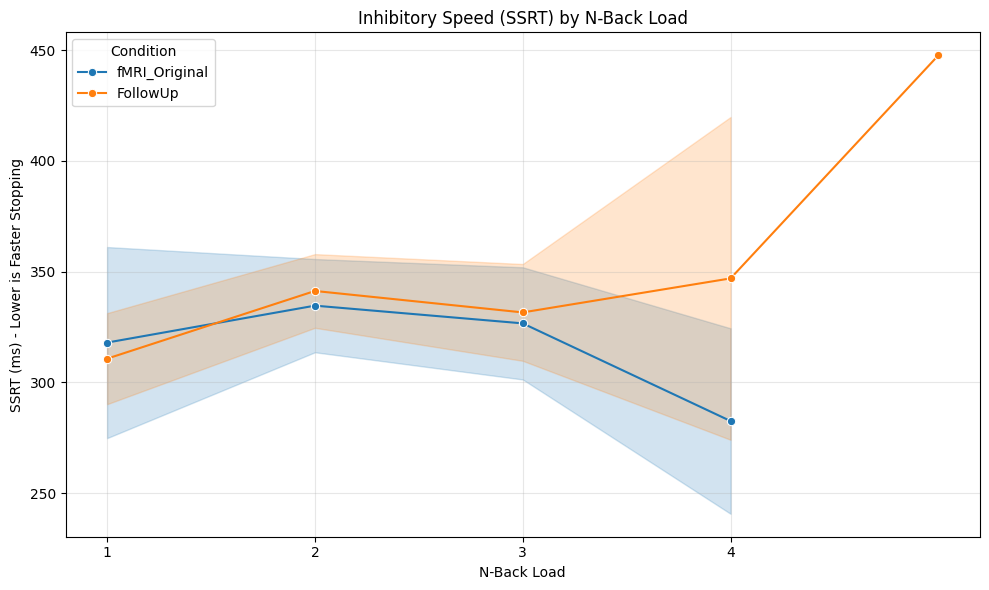

Mean SSRT per Load:
Load
1.0    315.15
2.0    337.55
3.0    328.74
4.0    321.21
5.0    447.75
Name: SSRT, dtype: float64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------
# SSRT ANALYSIS BY LOAD
# ---------------------------
ssrt_results = []
target_tasks = ["fMRI_Original", "FollowUp"]

for task in target_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # 1. Standardize Columns (Consistent with Cell 1)
    subj_col = next((c for c in df.columns if 'subj' in c.lower()), 'subject')
    acc_col = next((c for c in df.columns if 'stop' in c.lower() and 'acc' in c.lower()), None)
    load_col = next((c for c in df.columns if c.lower() == 'load'), 'Load')
    rt_col = info['rt_col']
    ssd_col = info.get('ssd_col')
    
    df.rename(columns={subj_col: 'subject', load_col: 'Load'}, inplace=True)

    # 2. Compute SSRT for each Subject at each Load level
    for (subj, load), subj_load_df in df.groupby(['subject', 'Load']):
        
        # Split into Go and Stop trials
        if 'NoStop1StopSuccess2StopFail3' in df.columns:
            go_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'] == 1]
            stop_trials = subj_load_df[subj_load_df['NoStop1StopSuccess2StopFail3'].isin([2, 3])]
        else:
            go_trials = subj_load_df[subj_load_df['stop_trial_type'] == 'go']
            stop_trials = subj_load_df[subj_load_df['stop_trial_type'] != 'go']

        # Check for sufficient data (need both trial types to compute SSRT)
        if len(go_trials) >= 5 and len(stop_trials) >= 5:
            # Integration Method Calculation
            p_respond = 1 - stop_trials[acc_col].mean()
            go_rts = np.sort(go_trials[rt_col].dropna().values)
            
            # Find the RT corresponding to the probability of responding
            n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
            n_idx = max(0, min(n_idx, len(go_rts) - 1))
            
            ssrt = go_rts[n_idx] - stop_trials[ssd_col].mean()
            
            ssrt_results.append({
                "subject": subj, 
                "Condition": task, 
                "Load": load, 
                "SSRT": ssrt
            })

# 3. Clean and Plot
ssrt_df = pd.DataFrame(ssrt_results)
# Remove outliers (SSRTs outside 50-800ms are usually invalid)
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 50) & (ssrt_df['SSRT'] <= 800)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=ssrt_df, x='Load', y='SSRT', hue='Condition', marker='o', errorbar='se')

plt.title("Inhibitory Speed (SSRT) by N-Back Load")
plt.ylabel("SSRT (ms) - Lower is Faster Stopping")
plt.xlabel("N-Back Load")
plt.xticks([1, 2, 3, 4])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean SSRT per Load:")
print(ssrt_df.groupby('Load')['SSRT'].mean().round(2))

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


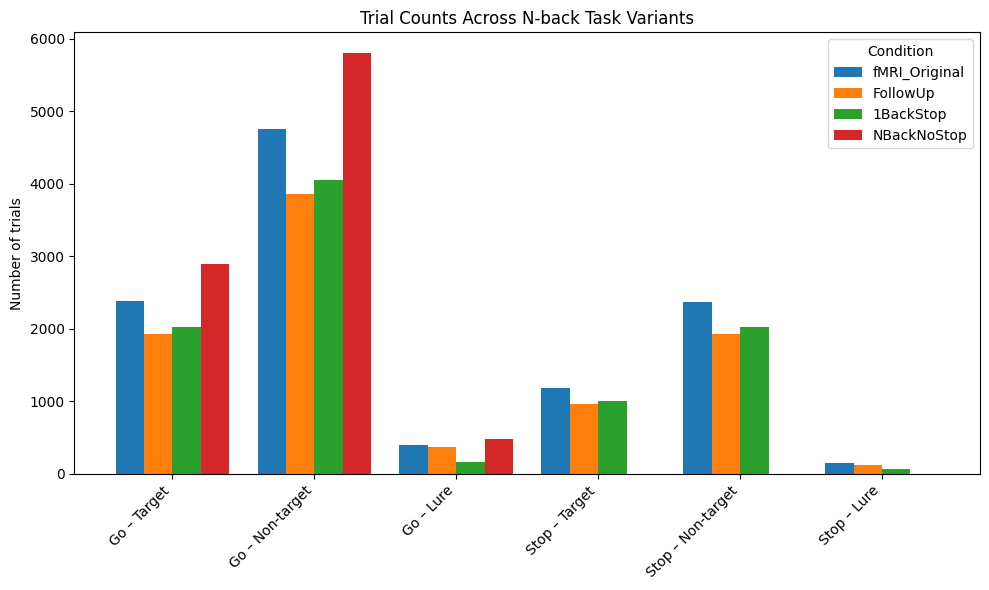

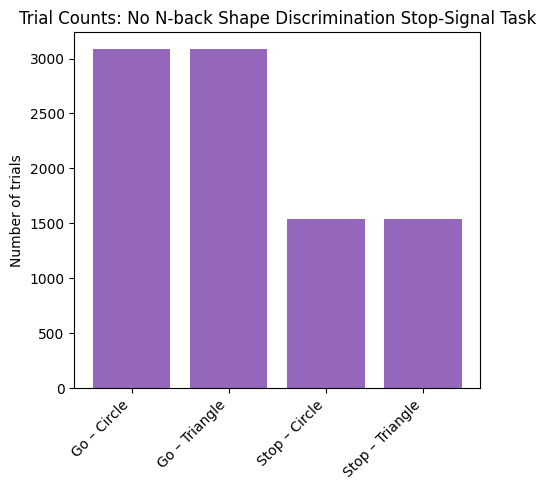

/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


            Task   n_go  n_stop  stop_signal_proportion
0  fMRI_Original   7529    3711                0.330160
1       FollowUp   6163    3024                0.329161
2      1BackStop   6236    3102                0.332191
3    NBackNoStop  18749       0                0.000000
4      ShapeStop   6168    3084                0.333333


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


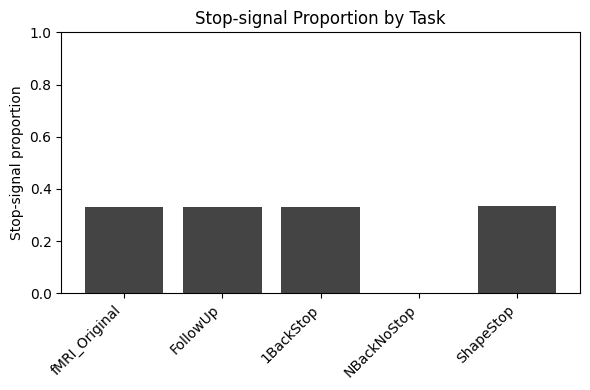

In [3]:
# ---------------------------
# Trial counts per condition x trial type
# ---------------------------

trial_counts_list = []

for task_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # ---- Stimulus label ----
    if task_name == "ShapeStop":
        df['stim_label'] = df[info['shape_col']].map(info['shape_map'])
    else:
        df['stim_label'] = df[info['stim_col']].map(info['stim_map'])

    # ---- Trial type ----
    if info['stop_go_col'] is not None:
        df['trial_type'] = df[info['stop_go_col']].map({info['stop_code']: 'Stop', info['go_code']: 'Go'})
        df['trial_label'] = df['trial_type'] + ' – ' + df['stim_label']
    else:
        df['trial_type'] = 'Go'
        df['trial_label'] = 'Go – ' + df['stim_label']

    # ---- Count trials per label ----
    counts = df.groupby('trial_label').size().reset_index(name='n_trials')
    counts['task'] = task_name
    trial_counts_list.append(counts)

# Combine all tasks
trial_counts = pd.concat(trial_counts_list, ignore_index=True)

# ---------------------------
# 1. Define trial types to include (for N-back)
# ---------------------------
trial_types_order = [
    "Go – Target", "Go – Non-target", "Go – Lure",
    "Stop – Target", "Stop – Non-target", "Stop – Lure"
]

# N-back tasks
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]

# ---------------------------
# 2. Pivot data for grouped bar plot
# ---------------------------
# Filter only N-back tasks
nback_counts = trial_counts[trial_counts["task"].isin(nback_tasks)]

# Pivot so that rows = trial_label, columns = task
pivot_df = nback_counts.pivot_table(
    index="trial_label",  # <-- corrected column name
    columns="task",
    values="n_trials",
    fill_value=0
)

# Reorder rows to desired trial type order
pivot_df = pivot_df.reindex(trial_types_order)

# ---------------------------
# 3. Plot grouped bar chart
# ---------------------------
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.2
x = np.arange(len(trial_types_order))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for i, task in enumerate(nback_tasks):
    ax.bar(x + i*bar_width, pivot_df[task], width=bar_width, label=task, color=colors[i])

ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(trial_types_order, rotation=45, ha="right")
ax.set_ylabel("Number of trials")
ax.set_title("Trial Counts Across N-back Task Variants")
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Plot ShapeStop separately
# ---------------------------
shape_data = trial_counts[trial_counts["task"] == "ShapeStop"].copy()

plt.figure(figsize=(5,5))
plt.bar(shape_data["trial_label"], shape_data["n_trials"], color="#9467bd")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of trials")
plt.title("Trial Counts: No N-back Shape Discrimination Stop-Signal Task")
plt.tight_layout()
plt.show()



# ---------------------------
# 5. Stop signal proportion
# ---------------------------


stop_props = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()

    # Total trials
    total_trials = len(df)

    stop_col = info.get('stop_go_col')
    go_code = info.get('go_code')
    stop_code = info.get('stop_code')

    if stop_col is not None and go_code is not None and stop_code is not None:
        n_stop = (df[stop_col] == stop_code).sum()
        n_go = (df[stop_col] == go_code).sum()
        prop = n_stop / (n_stop + n_go)
    else:
        # If no stop/go column, assume all go trials
        n_stop = 0
        n_go = total_trials
        prop = 0

    stop_props.append({
        "Task": task,
        "n_go": n_go,
        "n_stop": n_stop,
        "stop_signal_proportion": prop
    })

stop_props_df = pd.DataFrame(stop_props)
print(stop_props_df)

plt.figure(figsize=(6,4))
plt.bar(stop_props_df["Task"], stop_props_df["stop_signal_proportion"], color="#444444")
plt.ylabel("Stop-signal proportion")
plt.title("Stop-signal Proportion by Task")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


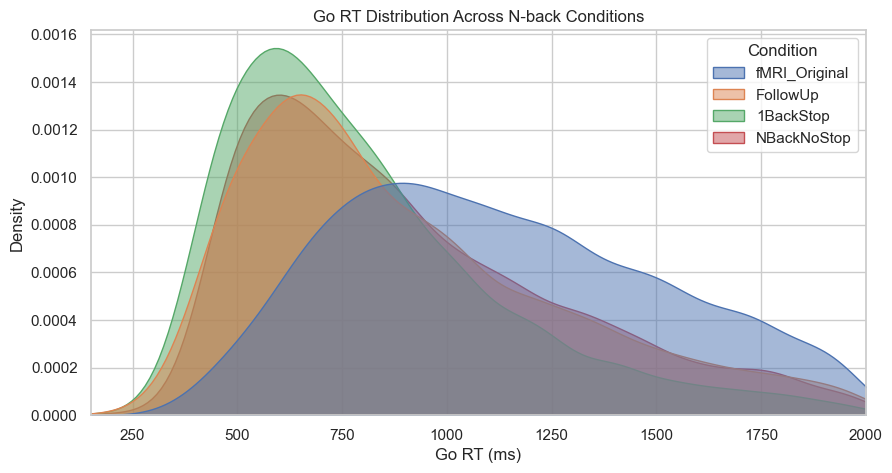

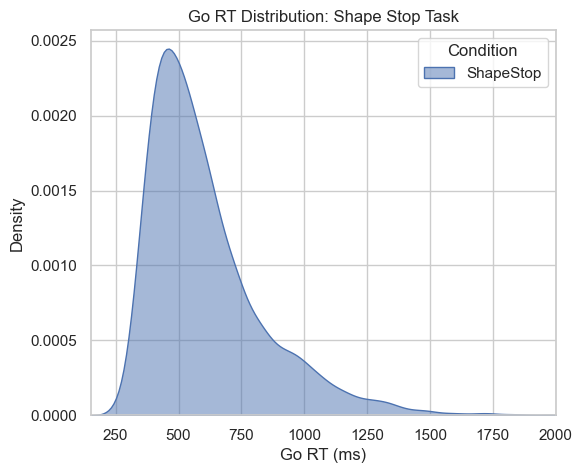

In [4]:
#-----------------------------------------
# Go RT Distribution Across N-back Conditions
#-----------------------------------------
##1. Prepare data for Go RTs
# ---------------------------
rt_list = []

for task, info in files_info.items():
    df = pd.read_excel(info["file"])
    
    # Clean subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # Only include tasks with a stop/go column for Go RT selection
    if info.get("stop_go_col") is not None:
        # Filter Go trials and realistic RTs
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df = df[df[info["stop_go_col"]] == info["go_code"]]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])
    else:
        # For tasks with no stop/go (ShapeStop), include all RTs within range
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])

rt_df = pd.concat(rt_list, ignore_index=True)

# ---------------------------
# 2. Split into N-back vs ShapeStop
# ---------------------------
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]
shape_task = ["ShapeStop"]

rt_nback = rt_df[rt_df["Condition"].isin(nback_tasks)]
rt_shape = rt_df[rt_df["Condition"].isin(shape_task)]

# ---------------------------
# 3. Plot Go RT distributions
# ---------------------------
sns.set(style="whitegrid")

# N-back panel
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=rt_nback, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution Across N-back Conditions")
plt.show()

# ShapeStop panel
plt.figure(figsize=(6,5))
sns.kdeplot(
    data=rt_shape, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution: Shape Stop Task")
plt.show()



/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: fMRI_Original   | Subjects: 30  | Mean Acc: 85.36%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: FollowUp        | Subjects: 23  | Mean Acc: 81.74%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: 1BackStop       | Subjects: 23  | Mean Acc: 90.91%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Task: NBackNoStop     | Subjects: 23  | Mean Acc: 89.92%
Task: ShapeStop       | Subjects: 23  | Mean Acc: 97.81%


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/2343130533.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')


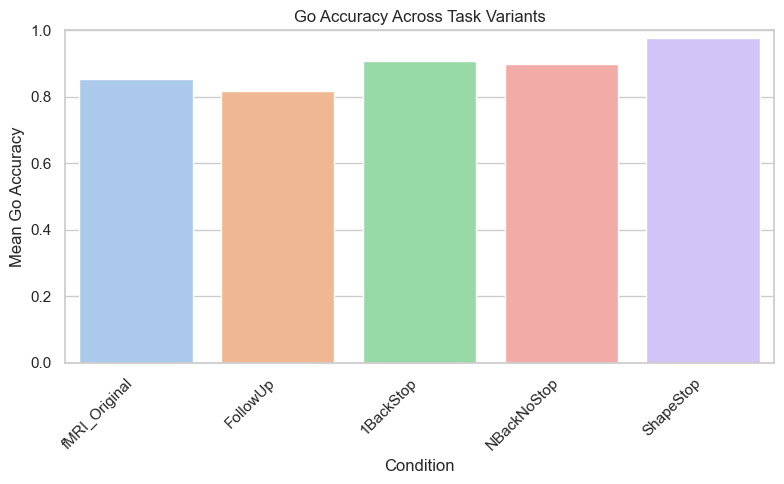

In [5]:
#-----------------------------------------
# Go Accuracy Across Task Variants
#-----------------------------------------
acc_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace

    # Standardize subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)

    # Filter Go trials if stop/go column exists
    if info.get('stop_go_col') is not None:
        go_df = df[df[info['stop_go_col']] == info['go_code']].copy()
    else:
        go_df = df.copy()  # everything is Go

    # Handle Go accuracy
    go_acc_col = info.get('go_acc')
    if go_acc_col is not None and go_acc_col in df.columns:
        go_df['acc'] = go_df[go_acc_col]
    else:
        # If no go_acc, use adaptive_acc if available
        if 'adaptive_acc' in df.columns:
            go_df['acc'] = go_df['adaptive_acc']
        else:
            # If no accuracy data, set as NaN
            go_df['acc'] = pd.Series([None] * len(go_df))

    # Compute mean accuracy per subject
    mean_acc = go_df.groupby('subject')['acc'].mean().reset_index()
    mean_acc['Condition'] = task
    
    task_avg = mean_acc['acc'].mean()
    print(f"Task: {task:<15} | Subjects: {len(mean_acc):<3} | Mean Acc: {task_avg:.2%}")
    #

    acc_list.append(mean_acc)

# Combine all tasks
acc_df = pd.concat(acc_list, ignore_index=True)

# Compute mean accuracy per condition, keeping NaN values if necessary
mean_acc_df = acc_df.groupby('Condition')['acc'].mean().reset_index()

# Optional: order conditions
condition_order = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop", "ShapeStop"]
mean_acc_df['Condition'] = pd.Categorical(mean_acc_df['Condition'], categories=condition_order, ordered=True)
mean_acc_df = mean_acc_df.sort_values('Condition')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=mean_acc_df, x='Condition', y='acc', palette='pastel')
plt.ylim(0,1)
plt.ylabel('Mean Go Accuracy')
plt.title('Go Accuracy Across Task Variants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


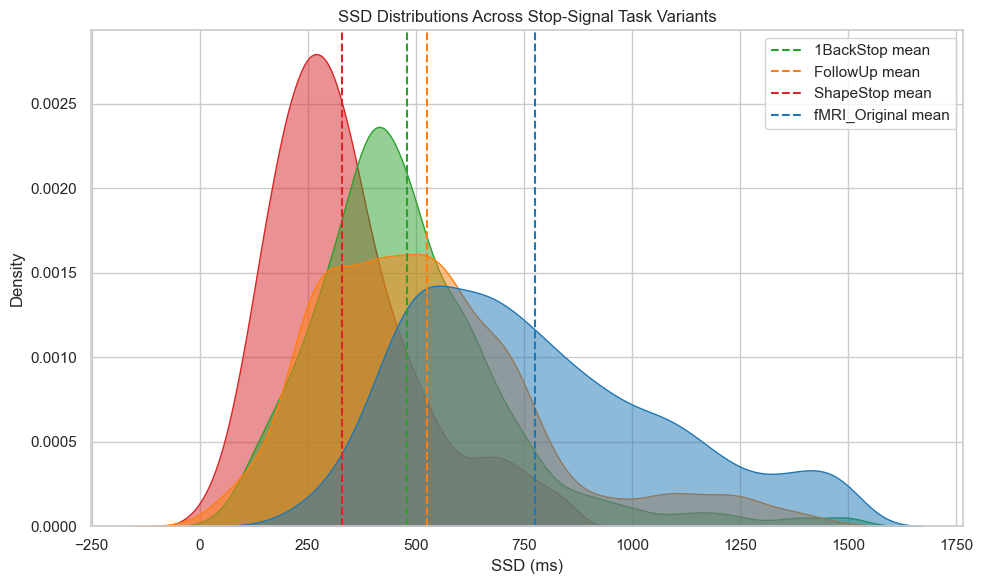

In [6]:
#-----------------------------------------
# SSD Distributions Across Stop-Signal Task Variants
# ---------------------------
# 1. Gather SSDs from all tasks
# ---------------------------
ssd_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove any weird spaces

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only include trials that have SSD (skip tasks without stop signals)
    if info.get('ssd_col') is not None:
        df = df[df[info['stop_go_col']] == info['stop_code']]  # only Stop trials
        df['Condition'] = task
        df['SSD'] = df[info['ssd_col']]
        ssd_list.append(df[['subject', 'Condition', 'SSD']])

# Combine all tasks
ssd_df = pd.concat(ssd_list, ignore_index=True)

# ---------------------------
# 2. Plot SSD distributions
# ---------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Define colors to match conditions
conditions = ssd_df['Condition'].unique()
palette = sns.color_palette("tab10", n_colors=len(conditions))
color_map = dict(zip(conditions, palette))

# KDE per task
sns.kdeplot(
    data=ssd_df,
    x='SSD',
    hue='Condition',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=color_map
)

# Overlay mean SSD as vertical lines with matching colors
mean_ssd = ssd_df.groupby('Condition')['SSD'].mean()
for cond, mean_val in mean_ssd.items():
    plt.axvline(mean_val, linestyle='--', color=color_map[cond], label=f'{cond} mean')

plt.xlabel("SSD (ms)")
plt.ylabel("Density")
plt.title("SSD Distributions Across Stop-Signal Task Variants")
plt.legend()
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/458669696.py:37: Fut

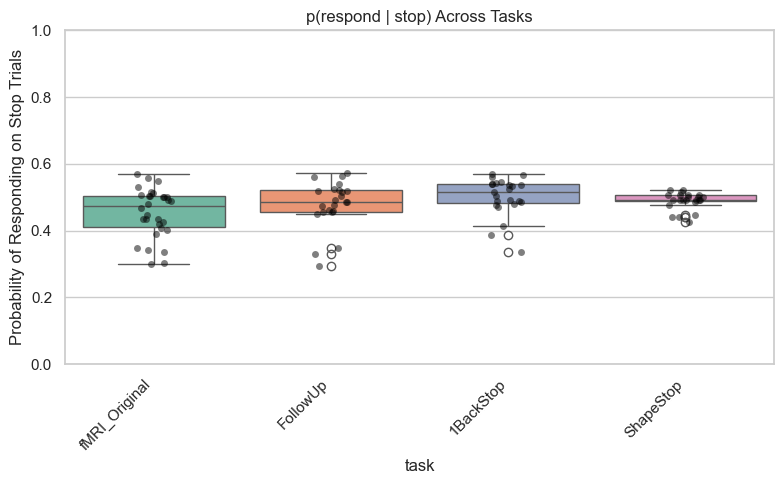

In [7]:

# ---------------------------
# Probability of responding on stop trials
# ---------------------------

# List to collect stop trial performance
stop_prob_list = []

for task, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # clean column names

    # Standardize subject column
    df.rename(columns={info['subject_col']: 'subject'}, inplace=True)

    # Only process tasks with stop trials
    if info.get('stop_go_col') is not None:
        # Identify stop trials
        stop_trials = df[df[info['stop_go_col']] == info['stop_code']].copy()
        
        # Probability of responding on stop trial: 1 = responded, 0 = successfully inhibited
        # If StopAcc column is 1 = successful stop, 0 = failed stop
        # Then responding = 1 - StopAcc
        stop_trials['responded'] = 1 - stop_trials[info['stop_acc_col']]

        # Compute mean per subject
        subj_mean = stop_trials.groupby('subject')['responded'].mean().reset_index()
        subj_mean['task'] = task
        stop_prob_list.append(subj_mean)

# Combine all tasks
stop_prob_df = pd.concat(stop_prob_list, ignore_index=True)

# ---------------------------
# Plot probability of responding given a stop signal
# ---------------------------
plt.figure(figsize=(8,5))
sns.boxplot(data=stop_prob_df, x='task', y='responded', palette="Set2")
sns.stripplot(data=stop_prob_df, x='task', y='responded', color='black', alpha=0.5, jitter=True)
plt.ylabel("Probability of Responding on Stop Trials")
plt.ylim(0,1)
plt.title("p(respond | stop) Across Tasks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/985954521.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  go_df = df[go_mask].copy()
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/985954521.py:54: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  go_df = df[go_mask].copy()


--- ACCURACY AUDIT ---
                count      mean       std  min  25%  50%  75%  max
Condition                                                         
FollowUp       6478.0  0.817536  0.386256  0.0  1.0  1.0  1.0  1.0
fMRI_Original  7529.0  0.853234  0.353896  0.0  1.0  1.0  1.0  1.0


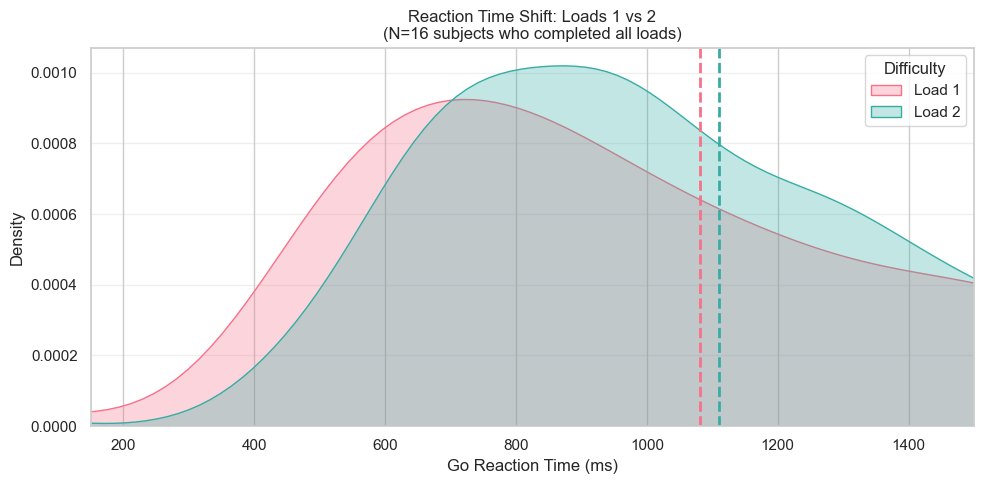

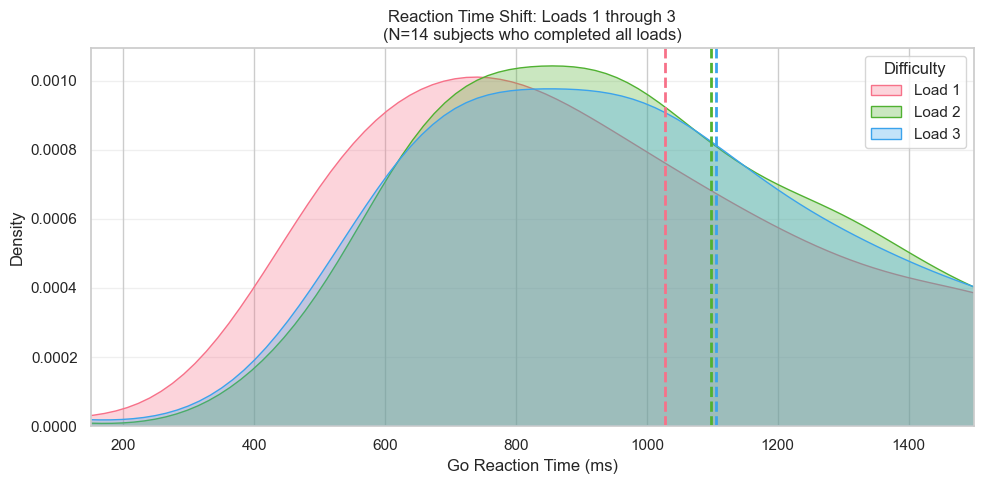

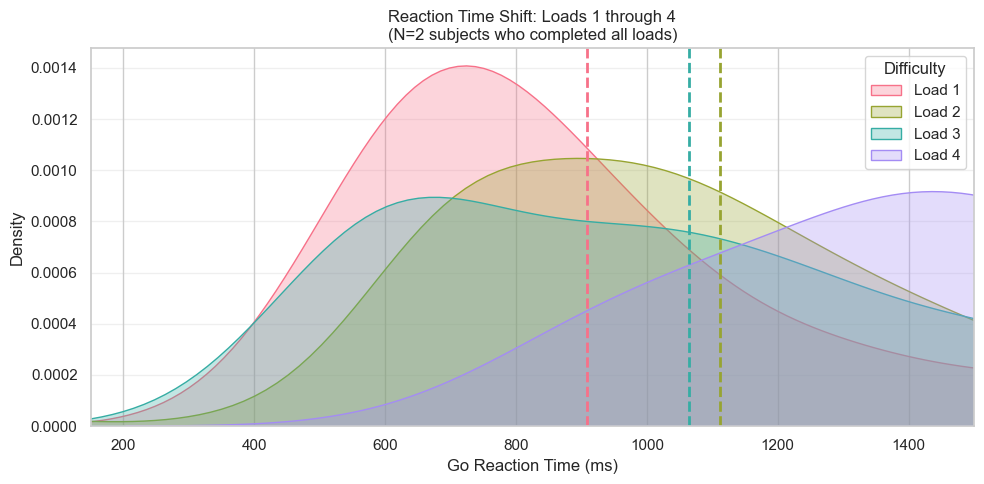

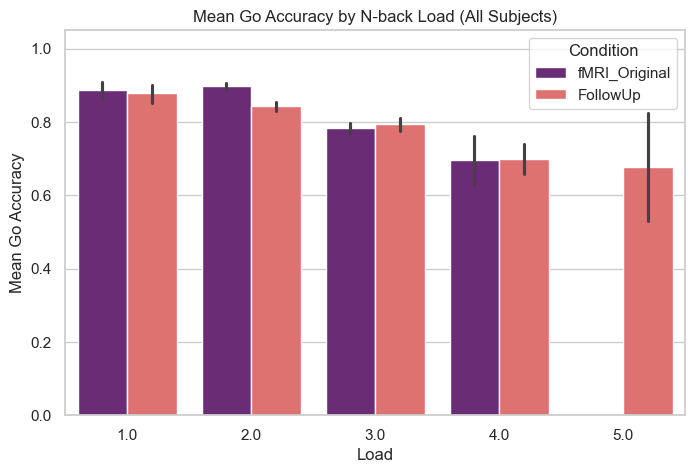

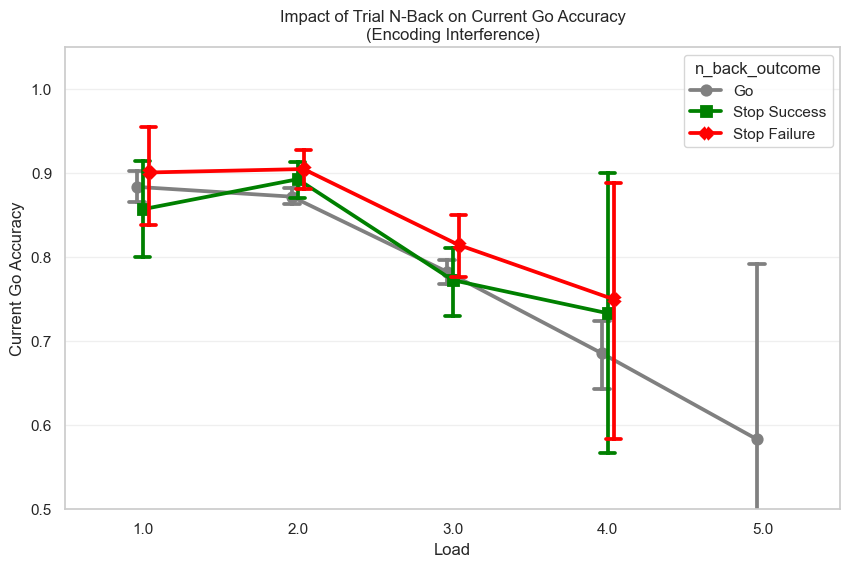

FollowUp Columns: ['RT', 'KeyPress', 'ITI', 'trial_id', 'trial_type', 'trial_index', 'time_elapsed', 'internal_node_id', 'exp_id', 'subject_id', 'stimulus', 'possible_responses', 'stim_duration', 'exp_stage', 'load', 'trial_num', 'stop_trial_type', 'adaptive_trial_type', 'stim', 'yes_response_key', 'no_response_key', 'SSD_target', 'SSD_non_target', 'SSTarget', 'SSNonTarget', 'go_acc', 'adaptive_acc', 'stop_acc', 'SS_stimulus', 'SS_trial_type', 'SS_duration', 'SS_delay', 'MainTask']


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [19]:
# ---------------------------
# Reaction times by load density plots, mean go accuracy by n-back load, 
# and impact of trial n-back on go accuracy (Encoding Interference)
# ---------------------------

# ---------------------------
# Data loading + cleaning
# ---------------------------

load_tasks = ["fMRI_Original", "FollowUp"]
all_go_trials = []

for task in load_tasks:
    if task not in files_info: continue
    info = files_info[task]
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()
    
    # --- 1. Standardize Columns ---
    sub_col = next((c for c in df.columns if 'subj' in c.lower()), None)
    df.rename(columns={sub_col: 'subject'}, inplace=True)
    
    tn_col = next((c for c in df.columns if 'trial' in c.lower() and 'num' in c.lower()), None)
    if tn_col: df.rename(columns={tn_col: 'TrialNum'}, inplace=True)
    
    load_col = next((c for c in df.columns if c.lower() == 'load'), None)
    if load_col: df['Load'] = df[load_col]

    # --- 2. Handle Accuracy (The 0.54 Fix) ---
    acc_col = next((c for c in df.columns if 'go' in c.lower() and 'acc' in c.lower()), None)
    if acc_col:
        df['acc'] = pd.to_numeric(df[acc_col], errors='coerce')
    
    # --- 3. Standardize outcomes & history for all trials- what happened on every trial + what happened right before it
    #  before filtering to not lose the Stop trials 
    
    if 'NoStop1StopSuccess2StopFail3' in df.columns:
        # fMRI Path
        outcome_map = {1: 'Go', 2: 'Stop Success', 3: 'Stop Failure'}
        df['current_outcome'] = df['NoStop1StopSuccess2StopFail3'].map(outcome_map)
        go_mask = (df['NoStop1StopSuccess2StopFail3'] == 1)
    elif 'stop_trial_type' in df.columns:
        # FollowUp Path
        df['current_outcome'] = df['stop_trial_type'].replace({'go': 'Go', 'succ': 'Stop Success', 'fail': 'Stop Failure'})
        go_mask = (df['stop_trial_type'] == 'go')
    
    # Ensure timeline is correct and shift history
    df = df.sort_values(['subject', 'TrialNum'])
    df['n_back_outcome'] = df.groupby('subject')['current_outcome'].shift(1)

    # --- 4. Final Go Trial Filter & Cleaning ---
    # Only keep current Go trials that have a valid accuracy score
    go_df = df[go_mask].copy()
    go_df = go_df.dropna(subset=['acc'])
    
    # --- 5. Accuracy Sanity Check ---
    # If it's still coded as 1/2 instead of 0/1, fix it
    if go_df['acc'].mean() > 1:
        go_df['acc'] = go_df['acc'].map({1: 1, 2: 0})
    
    go_df['Condition'] = task
    all_go_trials.append(go_df)

# the subjects, trial numbers, accuracy, and "what happened before" aligned across both experiments:
load_df = pd.concat(all_go_trials, ignore_index=True)
print("--- ACCURACY AUDIT ---")
print(load_df.groupby('Condition')['acc'].describe())

# ---------------------------------------------------------
# 2. COHORT IDENTIFICATION: go through whole dataset and list every person + every Load they attempted, create sets and check if their inventory contains all required loads.
# ---------------------------------------------------------
subj_load_sets = load_df.groupby('subject')['Load'].unique().apply(set)

def get_balanced_cohort(all_data, required_loads):
    req_set = set(required_loads)
    mask = subj_load_sets.apply(lambda x: req_set.issubset(x))
    valid_subjects = subj_load_sets[mask].index
    return all_data[all_data['subject'].isin(valid_subjects) & all_data['Load'].isin(required_loads)]

df_12   = get_balanced_cohort(load_df, [1, 2])
df_123  = get_balanced_cohort(load_df, [1, 2, 3])
df_1234 = get_balanced_cohort(load_df, [1, 2, 3, 4])

# ---------------------------
# 3. PLOTTING
# ---------------------------

# === PLOT 1: Go RT Distributions ===
def plot_cohort_dist(data, loads, title):
    if data.empty: return
    plt.figure(figsize=(10, 5))
    n_subj = data['subject'].nunique()
    colors = sns.color_palette("husl", len(loads))
    
    for i, load in enumerate(loads):
        subset = data[data['Load'] == load]
        sns.kdeplot(data=subset, x='RT', fill=True, alpha=0.3, color=colors[i], label=f"Load {load}")
        plt.axvline(subset['RT'].mean(), color=colors[i], linestyle='--', linewidth=2)
    
    plt.title(f"{title}\n(N={n_subj} subjects who completed all loads)")
    plt.xlabel("Go Reaction Time (ms)")
    plt.xlim(150, 1500)
    plt.legend(title="Difficulty")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_cohort_dist(df_12, [1, 2], "Reaction Time Shift: Loads 1 vs 2")
plot_cohort_dist(df_123, [1, 2, 3], "Reaction Time Shift: Loads 1 through 3")
plot_cohort_dist(df_1234, [1, 2, 3, 4], "Reaction Time Shift: Loads 1 through 4")

# === PLOT 2: Mean Go Accuracy by Load ===
plt.figure(figsize=(8,5))
sns.barplot(data=load_df, x='Load', y='acc', hue='Condition', palette='magma')
plt.ylabel("Mean Go Accuracy")
plt.ylim(0, 1.05)
plt.title("Mean Go Accuracy by N-back Load (All Subjects)")
plt.show()

# === PLOT 3: Encoding Interference (The "Fixed" Plot) ===
plt.figure(figsize=(10,6))
sns.pointplot(
    data=load_df, x='Load', y='acc', hue='n_back_outcome',
    hue_order=['Go', 'Stop Success', 'Stop Failure'],
    palette={'Go': 'gray', 'Stop Success': 'green', 'Stop Failure': 'red'},
    dodge=True, markers=['o', 's', 'X'], capsize=0.1
)
plt.title("Impact of Trial N-Back on Current Go Accuracy\n(Encoding Interference)")
plt.ylabel("Current Go Accuracy")
plt.ylim(0.5, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.show()

/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/1322100692.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_paired, x='subject', y='acc', hue='Load', palette='pastel', ci=None)


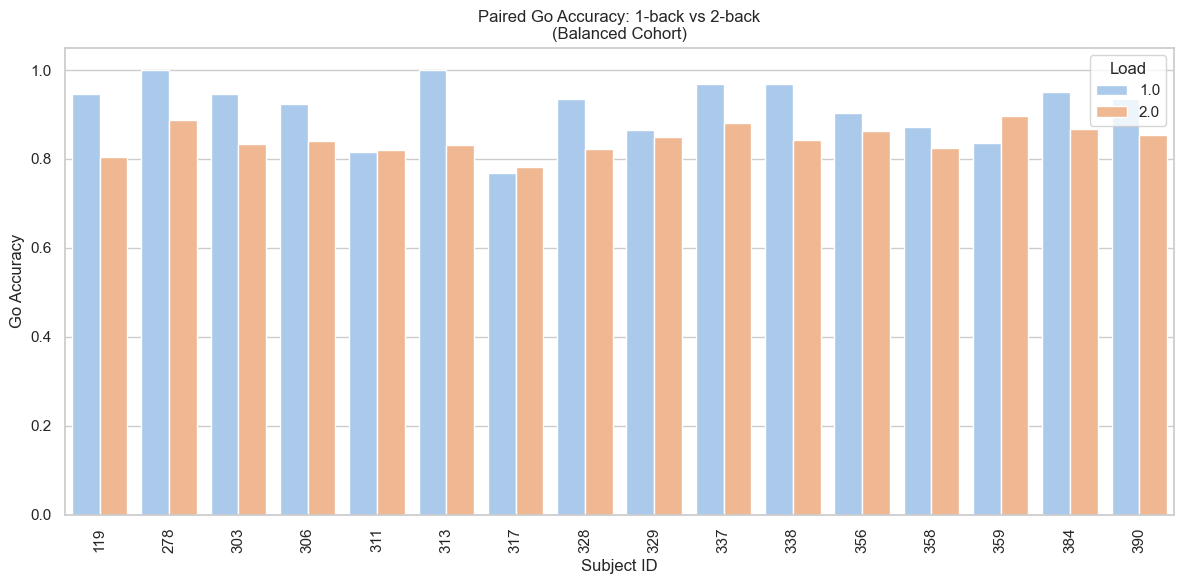

/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_43837/1322100692.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.lineplot(data=load_df, x='Load', y='acc', marker='o', color='blue', ci=68)


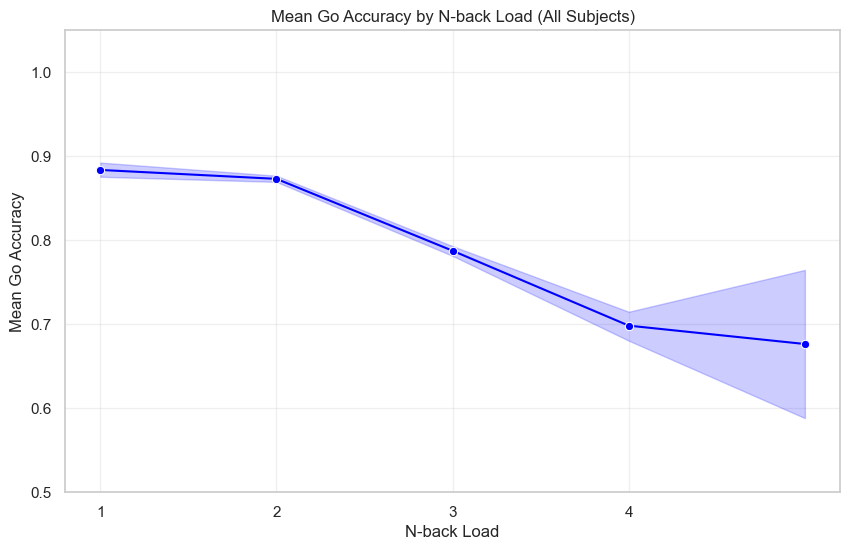

In [20]:
# ---------------------------------------------------------
# Go accuracy by load
# ---------------------------------------------------------

# 1. Use existing function to get the data of subjects who only completed both loads 1 and 2
df_paired = get_balanced_cohort(load_df, [1, 2])

# 2. Plot  directly
plt.figure(figsize=(12, 6))
sns.barplot(data=df_paired, x='subject', y='acc', hue='Load', palette='pastel', ci=None)

plt.xlabel('Subject ID')
plt.ylabel('Go Accuracy')
plt.title('Paired Go Accuracy: 1-back vs 2-back\n(Balanced Cohort)')
plt.xticks(rotation=90)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

# sns.lineplot calculates the mean AND the error bars (ci=68 is approx 1 SEM)
sns.lineplot(data=load_df, x='Load', y='acc', marker='o', color='blue', ci=68)

plt.xlabel('N-back Load')
plt.ylabel('Mean Go Accuracy')
plt.title('Mean Go Accuracy by N-back Load (All Subjects)')
plt.xticks([1, 2, 3, 4])
plt.ylim(0.5, 1.05) # Zoomed in to see the decline better
plt.grid(True, alpha=0.3)
plt.show()

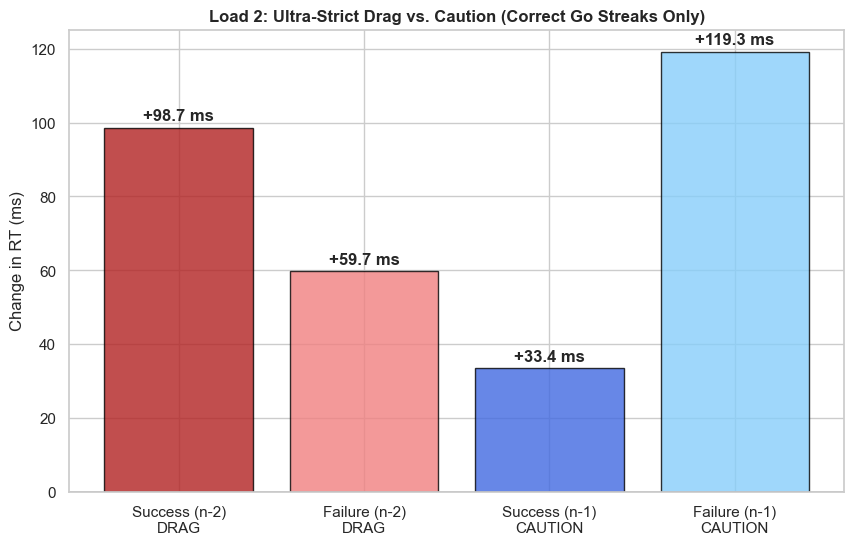

ULTRA-STRICT ANALYSIS RESULTS (LOAD 2):
Drag N: 16 subjects met the 3-trial CORRECT streak requirement.
Caution N: 16 subjects met the 3-trial CORRECT streak requirement.


In [56]:
# ----------------------------------------------------------------------------------
# LOAD 2: Analyzing drag vs caution (Correct Go Streaks Only)
# ----------------------------------------------------------------------------------

# 1. DEFINE ACCURACY AND SEQUENCING
df_go = df_go.sort_values(['subject', 'TrialNum'])

# Create 'is_correct_go' flag (RT > 0 ensures they didn't miss/omit)
df_go['is_correct_go'] = (df_go['NoStop1StopSuccess2StopFail3'] == 1) & (df_go['RT'] > 0)

# Shift accuracy status
df_go['n1_corr'] = df_go.groupby('subject')['is_correct_go'].shift(1)
df_go['n2_corr'] = df_go.groupby('subject')['is_correct_go'].shift(2)

# 2. SUBJECT-LEVEL CALCULATIONS (Get means AND counts)
# Isolate Drag (n-2): n-1 must be a Go trial AND it must be CORRECT
subj_drag_raw = df_go[(df_go['n1_type'] == 1) & (df_go['n1_corr'] == True)].groupby(['subject', 'n2_type'])['RT'].agg(['mean', 'count']).unstack()

# Isolate Caution (n-1): n-2 must be a Go trial AND it must be CORRECT
subj_caus_raw = df_go[(df_go['n2_type'] == 1) & (df_go['n2_corr'] == True)].groupby(['subject', 'n1_type'])['RT'].agg(['mean', 'count']).unstack()

# 3. APPLY MIN TRIALS FILTER (Requirement: 3 trials per condition)
drag_mask = (subj_drag_raw[('count', 1.0)] >= 3) & (subj_drag_raw[('count', 2.0)] >= 3) & (subj_drag_raw[('count', 3.0)] >= 3)
subj_drag = subj_drag_raw[drag_mask]['mean']

caus_mask = (subj_caus_raw[('count', 1.0)] >= 3) & (subj_caus_raw[('count', 2.0)] >= 3) & (subj_caus_raw[('count', 3.0)] >= 3)
subj_caus = subj_caus_raw[caus_mask]['mean']

# 4. NORMALIZE (Subtract Baseline)
drag_diffs = subj_drag.subtract(subj_drag[1.0], axis=0)
caus_diffs = subj_caus.subtract(subj_caus[1.0], axis=0)

# 5. FINAL GROUP AVERAGES
final_vals = [
    drag_diffs[2.0].mean(), # Success Drag
    drag_diffs[3.0].mean(), # Failure Drag
    caus_diffs[2.0].mean(), # Success Caution
    caus_diffs[3.0].mean()  # Failure Caution
]

# ---------------------------------------------------------
# 6. VISUALIZATION
# ---------------------------------------------------------
labels = ['Success (n-2)\nDRAG', 'Failure (n-2)\nDRAG', 
          'Success (n-1)\nCAUTION', 'Failure (n-1)\nCAUTION']

plt.figure(figsize=(10, 6))
colors = ['firebrick', 'lightcoral', 'royalblue', 'lightskyblue']
bars = plt.bar(labels, final_vals, color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)

for bar in bars:
    y = bar.get_height()
    if pd.notnull(y):
        plt.text(bar.get_x() + bar.get_width()/2, y + (2 if y >= 0 else -10), 
                 f'+{y:.1f} ms' if y > 0 else f'{y:.1f} ms', ha='center', fontweight='bold')

plt.title('Load 2: Ultra-Strict Drag vs. Caution (Correct Go Streaks Only)', fontsize=12, fontweight='bold')
plt.ylabel('Change in RT (ms)')
plt.show()

print(f"ULTRA-STRICT ANALYSIS RESULTS (LOAD 2):")
print(f"Drag N: {len(drag_diffs.dropna())} subjects met the 3-trial CORRECT streak requirement.")
print(f"Caution N: {len(caus_diffs.dropna())} subjects met the 3-trial CORRECT streak requirement.")

In [59]:
# --- FULL LOAD 2 AUDIT

# 1. PRE-FILTER: Create the "Correct Go" flag (Match Graph Step 1)
df_go = df_go.sort_values(['subject', 'TrialNum'])
df_go['is_correct_go'] = (df_go['NoStop1StopSuccess2StopFail3'] == 1) & (df_go['RT'] > 0)
df_go['n1_corr'] = df_go.groupby('subject')['is_correct_go'].shift(1)
df_go['n2_corr'] = df_go.groupby('subject')['is_correct_go'].shift(2)

# 2. GLOBAL MEAN
load2_global_mean = df_go[df_go['is_correct_go']].groupby('subject')['RT'].mean()

# 3. DRAG (n-2) - Filter: n-1 must be a CORRECT Go (Match Graph Step 2)
audit_l2_drag = df_go[(df_go['n1_type'] == 1) & (df_go['n1_corr'] == True)].groupby(['subject', 'n2_type'])['RT'].agg(['mean', 'count']).unstack()
audit_l2_drag.columns = [f"{col[0]}_{int(col[1])}" for col in audit_l2_drag.columns]

# 4. CAUTION (n-1) - Filter: n-2 must be a CORRECT Go (Match Graph Step 2)
audit_l2_caus = df_go[(df_go['n2_type'] == 1) & (df_go['n2_corr'] == True)].groupby(['subject', 'n1_type'])['RT'].agg(['mean', 'count']).unstack()
audit_l2_caus.columns = [f"{col[0]}_{int(col[1])}" for col in audit_l2_caus.columns]

# 5. PROCESS DRAG & APPLY MIN_TRIALS
audit_l2_drag = audit_l2_drag.rename(columns={
    'mean_1': 'RT_Base_Drag', 'count_1': 'N_Base_Drag',
    'mean_2': 'RT_Succ_n2', 'count_2': 'N_Succ_n2', 
    'mean_3': 'RT_Fail_n2', 'count_3': 'N_Fail_n2'
})

# Use the NEW names ('N_Succ_n2' instead of 'count_2')
drag_mask = (audit_l2_drag['N_Base_Drag'] >= 3) & \
            (audit_l2_drag['N_Succ_n2'] >= 3) & \
            (audit_l2_drag['N_Fail_n2'] >= 3)

audit_l2_drag = audit_l2_drag[drag_mask].copy() 
audit_l2_drag['Drag_Success'] = audit_l2_drag['RT_Succ_n2'] - audit_l2_drag['RT_Base_Drag']
audit_l2_drag['Drag_Failure'] = audit_l2_drag['RT_Fail_n2'] - audit_l2_drag['RT_Base_Drag']

# 6. PROCESS CAUTION & APPLY MIN_TRIALS
audit_l2_caus = audit_l2_caus.rename(columns={
    'mean_1': 'RT_Base_Caus', 'count_1': 'N_Base_Caus',
    'mean_2': 'RT_Succ_n1', 'count_2': 'N_Succ_n1', 
    'mean_3': 'RT_Fail_n1', 'count_3': 'N_Fail_n1'
})

# Use the NEW names ('N_Fail_n1' instead of 'count_3')
caus_mask = (audit_l2_caus['N_Base_Caus'] >= 3) & \
            (audit_l2_caus['N_Succ_n1'] >= 3) & \
            (audit_l2_caus['N_Fail_n1'] >= 3)

audit_l2_caus = audit_l2_caus[caus_mask].copy()
audit_l2_caus['Caution_Success'] = audit_l2_caus['RT_Succ_n1'] - audit_l2_caus['RT_Base_Caus']
audit_l2_caus['Caution_Failure'] = audit_l2_caus['RT_Fail_n1'] - audit_l2_caus['RT_Base_Caus']

# 7. COMBINE
master_l2 = pd.concat([audit_l2_drag, audit_l2_caus], axis=1)
master_l2['Overall_Mean_L2'] = load2_global_mean
print("--- LOAD 2: ULTRA-STRICT AUDIT (MATCHES GRAPH) ---")
cols_to_show = ['Overall_Mean_L2', 'RT_Base_Caus', 'RT_Fail_n1', 'Caution_Failure', 'RT_Base_Drag', 'RT_Succ_n2', 'Drag_Success']
print(master_l2[cols_to_show].round(1))

print("\n" + "="*40)
print(f"Graph Check - Caution (Failure): {master_l2['Caution_Failure'].mean():.1f} ms")
print(f"Graph Check - Drag (Success):    {master_l2['Drag_Success'].mean():.1f} ms")
print("="*40)

--- LOAD 2: ULTRA-STRICT AUDIT (MATCHES GRAPH) ---
         Overall_Mean_L2  RT_Base_Caus  RT_Fail_n1  Caution_Failure  \
subject                                                               
119               1327.7        1224.7      1499.9            275.2   
278                766.5         725.5       789.5             64.1   
303               1636.3        1635.6      1812.1            176.6   
306                919.5         939.3       960.2             20.9   
311               1282.0        1242.1      1392.3            150.2   
313               1403.1        1333.4      1645.5            312.1   
317               1370.6        1424.3      1223.0           -201.3   
328               1256.2        1247.1      1434.4            187.2   
329               1121.5        1055.5      1115.8             60.3   
337               1138.5        1065.1      1145.7             80.5   
338                862.2         803.1      1028.3            225.1   
356                917.3  

ULTRA-STRICT RESULTS:
Success N: 5 subjects
Failure N: 3 subjects


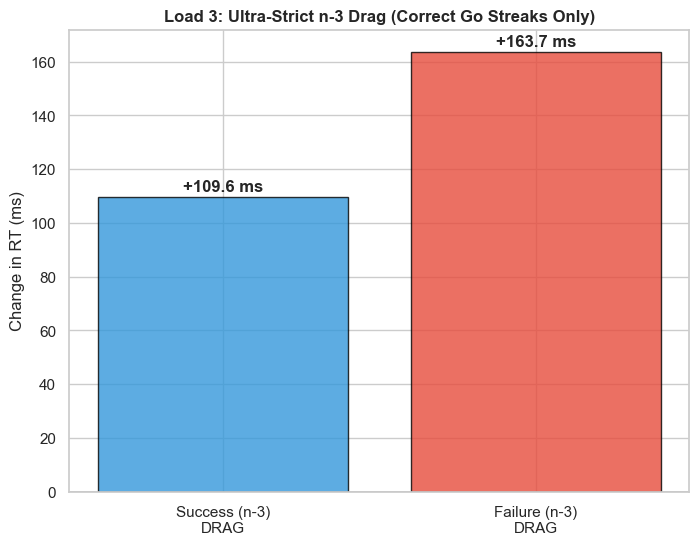

ULTRA-STRICT RESULTS:
Final N: 3 subjects met the 3-trial CORRECT streak requirement.


In [65]:
# ----------------------------------------------------------------------------------
# LOAD 3: Does drag increase at a higher workload? (Correct Go Streaks Only)
# ----------------------------------------------------------------------------------

# 1. SEQUENCING & ACCURACY FILTER
full_load3 = full_load3.sort_values(['subject', 'TrialNum'])

# Create a 'Correct Go' flag (Adjust 'RT > 0' if you have a specific accuracy column)
full_load3['is_correct_go'] = (full_load3['NoStop1StopSuccess2StopFail3'] == 1) & (full_load3['RT'] > 0)

# Shift the accuracy/type status
full_load3['n1_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(1)
full_load3['n1_corr'] = full_load3.groupby('subject')['is_correct_go'].shift(1)

full_load3['n2_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(2)
full_load3['n2_corr'] = full_load3.groupby('subject')['is_correct_go'].shift(2)

full_load3['n3_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(3)

# Filter for the current trial being a Correct Go
df_go_l3 = full_load3[(full_load3['NoStop1StopSuccess2StopFail3'] == 1) & (full_load3['RT'] > 0)].copy()

# 2. SUBJECT-LEVEL CALCULATION
# REQUIREMENT: n-1 and n-2 must be Go trials AND they must be CORRECT
# This ensures no Post-Error Slowing is bleeding into the Drag measurement.
strict_sequence_mask = (df_go_l3['n1_type'] == 1) & (df_go_l3['n1_corr'] == True) & \
                       (df_go_l3['n2_type'] == 1) & (df_go_l3['n2_corr'] == True)

subj_drag_n3_raw = df_go_l3[strict_sequence_mask].groupby(['subject', 'n3_type'])['RT'].agg(['mean', 'count']).unstack()

# Calculate the raw differences for EVERYONE first
raw_diffs_n3 = subj_drag_n3_raw['mean'].subtract(subj_drag_n3_raw[('mean', 1.0)], axis=0)

# 5. FINAL GROUP AVERAGES ( reliability filters independently for each bar)

# Success bar: People with 3+ Baseline AND 3+ Success
succ_filter = (subj_drag_n3_raw[('count', 1.0)] >= 3) & (subj_drag_n3_raw[('count', 2.0)] >= 3)
val_succ = raw_diffs_n3[2.0][succ_filter].mean()

# Failure bar: People with 3+ Baseline AND 3+ Failure
fail_filter = (subj_drag_n3_raw[('count', 1.0)] >= 3) & (subj_drag_n3_raw[('count', 3.0)] >= 3)
val_fail = raw_diffs_n3[3.0][fail_filter].mean()

final_vals_l3 = [val_succ, val_fail]

# Update the print statement to show both Ns
print(f"ULTRA-STRICT RESULTS:")
print(f"Success N: {succ_filter.sum()} subjects")
print(f"Failure N: {fail_filter.sum()} subjects")
# ---------------------------------------------------------
# 6. VISUALIZATION 
# ---------------------------------------------------------
labels = ['Success (n-3)\nDRAG', 'Failure (n-3)\nDRAG']
colors = ['#3498db', '#e74c3c']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, final_vals_l3, color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)

for bar in bars:
    y = bar.get_height()
    if pd.notnull(y):
        plt.text(bar.get_x() + bar.get_width()/2, y + (2 if y >= 0 else -10), 
                 f'{y:+.1f} ms', ha='center', fontweight='bold')

plt.title('Load 3: Ultra-Strict n-3 Drag (Correct Go Streaks Only)', fontsize=12, fontweight='bold')
plt.ylabel('Change in RT (ms)')
plt.show()

print(f"ULTRA-STRICT RESULTS:")
print(f"Final N: {len(drag_diffs_n3.dropna())} subjects met the 3-trial CORRECT streak requirement.")

In [62]:
# --- Load 3 Audit

# 1. SEQUENCING & ACCURACY (Ensures n-1 and n-2 were Correct Go trials)
full_load3 = full_load3.sort_values(['subject', 'TrialNum'])
full_load3['is_correct_go'] = (full_load3['NoStop1StopSuccess2StopFail3'] == 1) & (full_load3['RT'] > 0)

full_load3['n1_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(1)
full_load3['n1_corr'] = full_load3.groupby('subject')['is_correct_go'].shift(1)

full_load3['n2_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(2)
full_load3['n2_corr'] = full_load3.groupby('subject')['is_correct_go'].shift(2)

full_load3['n3_type'] = full_load3.groupby('subject')['NoStop1StopSuccess2StopFail3'].shift(3)

# Filter for current trials that are Correct Go, where the history was also Correct Go
# This is the "Clean Streak" logic
df_clean_l3 = full_load3[
    (full_load3['is_correct_go'] == True) & 
    (full_load3['n1_type'] == 1) & (full_load3['n1_corr'] == True) &
    (full_load3['n2_type'] == 1) & (full_load3['n2_corr'] == True)
].copy()

# 2. GROUPING
audit_raw = df_clean_l3.groupby(['subject', 'n3_type'])['RT'].agg(['mean', 'count']).unstack()
audit_raw.columns = [f"{col[0]}_{int(col[1])}" for col in audit_raw.columns]

# 3. RENAME DESCRIPTIVE COLUMNS
rename_dict = {
    'mean_1': 'RT_Base_n3', 'count_1': 'N_Base_n3',
    'mean_2': 'RT_Succ_n3', 'count_2': 'N_Succ_n3',
    'mean_3': 'RT_Fail_n3', 'count_3': 'N_Fail_n3'
}
audit_load3 = audit_raw.rename(columns=rename_dict)

# 4. CALCULATE INDIVIDUAL DRAG
audit_load3['Drag_Success'] = audit_load3['RT_Succ_n3'] - audit_load3['RT_Base_n3']
audit_load3['Drag_Failure'] = audit_load3['RT_Fail_n3'] - audit_load3['RT_Base_n3']
audit_load3['Overall_Mean_L3'] = full_load3[full_load3['is_correct_go']].groupby('subject')['RT'].mean()

# 5. PRINT THE AUDIT TABLE
print("--- LOAD 3 AUDIT ---")
cols_to_show = ['Overall_Mean_L3', 'RT_Base_n3', 'RT_Succ_n3', 'N_Succ_n3', 'Drag_Success', 'RT_Fail_n3', 'N_Fail_n3', 'Drag_Failure']
existing_cols = [c for c in cols_to_show if c in audit_load3.columns]
print(audit_load3[existing_cols].round(1))

# 6. CALCULATE GRAPH TOTALS (Requiring 3 trials for the Baseline AND the Target)
# Success bar
success_mask = (audit_load3['N_Base_n3'] >= 3) & (audit_load3['N_Succ_n3'] >= 3)
reliable_success = audit_load3[success_mask]['Drag_Success'].mean()

# Failure bar
failure_mask = (audit_load3['N_Base_n3'] >= 3) & (audit_load3['N_Fail_n3'] >= 3)
reliable_failure = audit_load3[failure_mask]['Drag_Failure'].mean()

print("\n" + "="*40)
print(f"Graph Check - Success Drag: {reliable_success:.1f} ms (N={success_mask.sum()})")
print(f"Graph Check - Failure Drag: {reliable_failure:.1f} ms (N={failure_mask.sum()})")
print("="*40)

# --- MANUAL SUCCESS DRAG COMPARISON ---

# 1. The 'All 7' Average (Includes Subjects 313 and 384 who had < 3 trials)
all_7_mean = audit_load3['Drag_Success'].mean()

# 2. The 'Reliable 5' Average (Matches your Graph)
# We filter the index to only include the IDs of people with 3+ trials
reliable_ids = [119, 278, 303, 337, 358]
reliable_5_mean = audit_load3.loc[reliable_ids, 'Drag_Success'].mean()

print(f"Comparison of Success Drag Calculation:")
print(f"Average of all 7 subjects: {all_7_mean:.1f} ms")
print(f"Average of ONLY the 5 reliable subjects: {reliable_5_mean:.1f} ms (Matches Graph)")

--- LOAD 3 AUDIT ---
         Overall_Mean_L3  RT_Base_n3  RT_Succ_n3  N_Succ_n3  Drag_Success  \
subject                                                                     
119               1483.6      1454.9      1702.4        5.0         247.5   
278                798.2       779.2      1120.3        6.0         341.1   
303               1584.9      1627.2      1718.7        3.0          91.5   
313               1763.8      1912.2      2255.0        1.0         342.8   
337               1199.4      1254.3      1159.2        6.0         -95.2   
358               1153.0       985.3       948.3        3.0         -37.0   
384               1772.1      1748.3      2261.5        2.0         513.2   

         RT_Fail_n3  N_Fail_n3  Drag_Failure  
subject                                       
119          1887.5        2.0         432.6  
278           869.7        7.0          90.5  
303             NaN        NaN           NaN  
313          1599.0        2.0        -313.2  
337

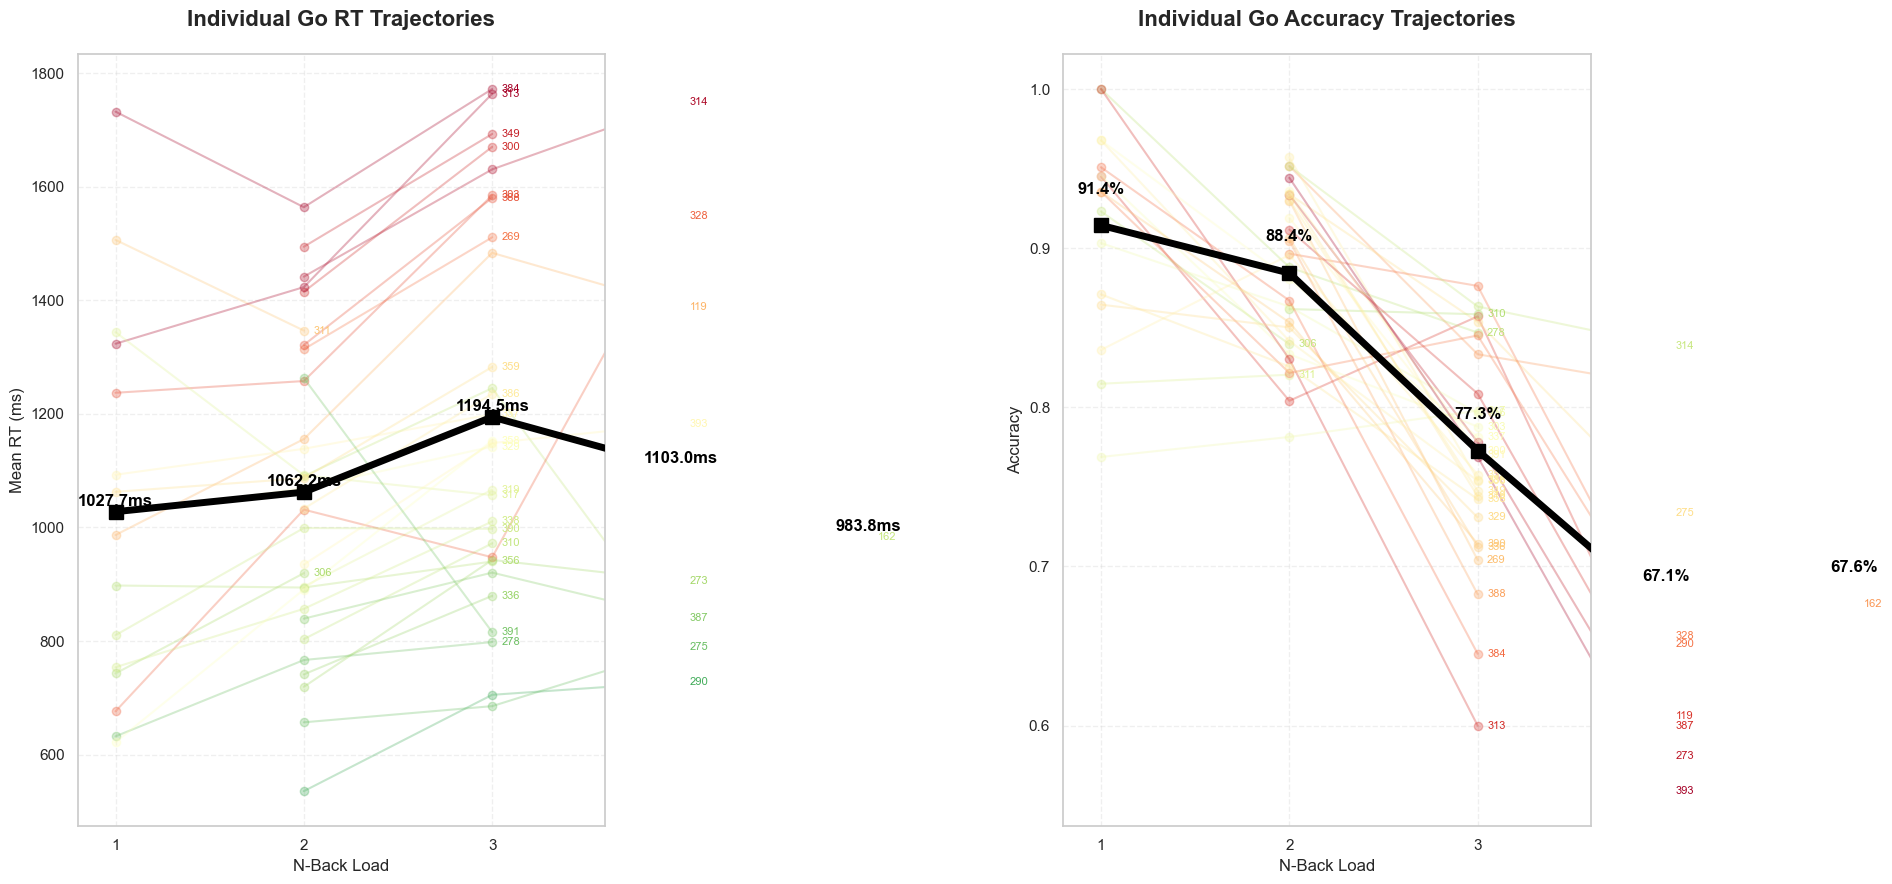

--- TOTAL GROUP GO ACCURACY BY LOAD ---
Load 1: 88.37%
Load 2: 87.31%
Load 3: 78.75%
Load 4: 69.83%
Load 5: 67.65%


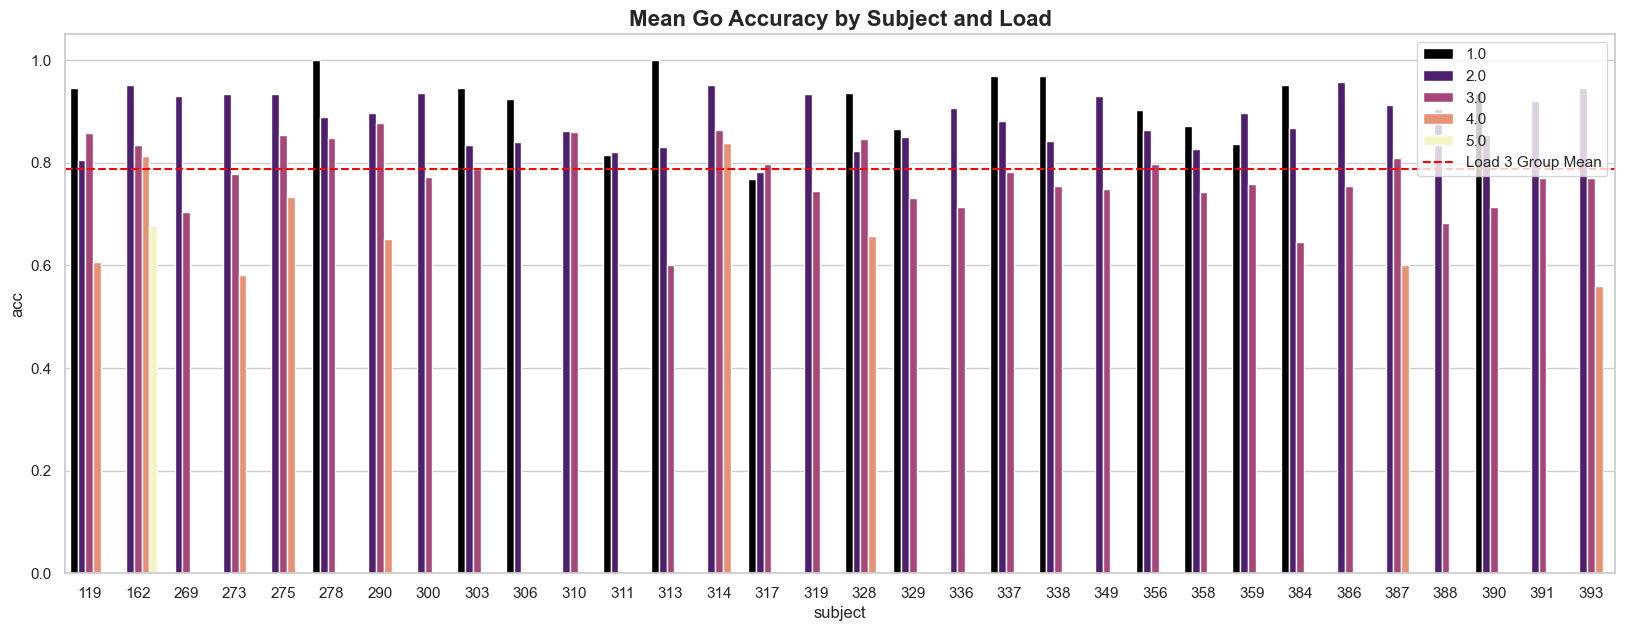

In [66]:
# 1. Use the ALREADY standardized load_df
subject_stats = load_df.groupby(['subject', 'Load'])[['RT', 'acc']].mean().reset_index()

# calculate the overall mean across all participants for each load level
group_summary = load_df.groupby('Load')['acc'].mean().reset_index()
group_summary['acc_pct'] = group_summary['acc'] * 100 # Convert to percentage for easy reading

# 2. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

def high_vis_plot(data, y_col, title, ax):
    if data.empty: 
        print(f"No data found for {y_col}")
        return

    norm = plt.Normalize(data[y_col].min(), data[y_col].max())
    cmap = plt.cm.RdYlGn_r if y_col == 'RT' else plt.cm.RdYlGn
    
    for subj in data['subject'].unique():
        subj_data = data[data['subject'] == subj].sort_values('Load')
        last_val = subj_data[y_col].iloc[-1]
        color = cmap(norm(last_val))
        ax.plot(subj_data['Load'], subj_data[y_col], marker='o', color=color, alpha=0.3, linewidth=1.5)
        last_load = subj_data['Load'].iloc[-1]
        ax.text(last_load + 0.05, last_val, f"{int(subj)}", fontsize=8, color=color, va='center')

    # Add the "Group Average" - Thick black line
    avg_data = data.groupby('Load')[y_col].mean().reset_index()
    ax.plot(avg_data['Load'], avg_data[y_col], color='black', linewidth=5, marker='s', markersize=10, label='GROUP AVG', zorder=100)
    
    # Add Text Labels for the Group Averages so you can see the % on the chart
    for i, row in avg_data.iterrows():
        val_display = f"{row[y_col]:.1f}ms" if y_col == 'RT' else f"{row[y_col]*100:.1f}%"
        ax.text(row['Load'], row[y_col] + (0.02 if y_col == 'acc' else 10), 
                val_display, color='black', fontweight='bold', ha='center', fontsize=12)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('N-Back Load', fontsize=12)
    ax.set_ylabel('Mean RT (ms)' if y_col == 'RT' else 'Accuracy', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(0.8, 3.6)

# Run the plotting functions
high_vis_plot(subject_stats, 'RT', 'Individual Go RT Trajectories', ax1)
high_vis_plot(subject_stats, 'acc', 'Individual Go Accuracy Trajectories', ax2)

plt.tight_layout()
plt.show()

# --- summary
print("--- TOTAL GROUP GO ACCURACY BY LOAD ---")
for _, row in group_summary.iterrows():
    print(f"Load {int(row['Load'])}: {row['acc_pct']:.2f}%")

# --- BAR PLOTS ---
plt.figure(figsize=(20, 7))
sns.barplot(data=subject_stats, x='subject', y='acc', hue='Load', palette='magma')
plt.title('Mean Go Accuracy by Subject and Load', fontsize=16, fontweight='bold')
plt.axhline(group_summary[group_summary['Load']==3]['acc'].values[0], 
            color='red', linestyle='--', label='Load 3 Group Mean')
plt.legend()
plt.show()